In [6]:
import os
import pandas as pd

# 获取当前工作目录
cwd = os.getcwd()
print("当前工作目录:", cwd)

# 判断当前是否在 evaluation 文件夹内
if os.path.basename(cwd) == 'evaluation':
    # 如果在 evaluation 内，则项目根目录为上一级
    base_dir = os.path.dirname(cwd)
else:
    # 否则假设已经在项目根目录
    base_dir = cwd

log_path = os.path.join(base_dir, 'logs', 'evaluation_logs.csv')
print("尝试读取日志文件:", log_path)

# 检查文件是否存在
if os.path.exists(log_path):
    df = pd.read_csv(log_path)
    print("文件读取成功！前几行数据如下：")
    print(df.head())
else:
    print("错误：日志文件不存在，请确认路径。")

当前工作目录: D:\GameAI_Evaluation_Sandbox
尝试读取日志文件: D:\GameAI_Evaluation_Sandbox\logs\evaluation_logs.csv
文件读取成功！前几行数据如下：
   episode   scenario        agent  step  pos_x  pos_y   action  collected  \
0        0  scenario1  RandomAgent     0      1      0     down          0   
1        0  scenario1  RandomAgent     1      1      0  collect          0   
2        0  scenario1  RandomAgent     2      1      0     left          0   
3        0  scenario1  RandomAgent     3      2      0     down          0   
4        0  scenario1  RandomAgent     4      2      0     left          0   

    done  
0  False  
1  False  
2  False  
3  False  
4  False  


In [7]:
# 定义每个场景的物品数量（根据你的 JSON 文件调整）
# 请打开 scenarios 文件夹下的 JSON 文件，数一下 "I" 的数量
item_counts = {
    'scenario1': 1,   # 如果实际物品数不是 1，请修改
    'scenario2': 3,
    'scenario3': 2
}

# 获取每个 episode 的最后一步
last_steps = df.groupby(['episode', 'scenario', 'agent']).last().reset_index()
last_steps['total_items'] = last_steps['scenario'].map(item_counts)
last_steps['success'] = (last_steps['done'] == True) & (last_steps['collected'] == last_steps['total_items'])

# 显示前几行检查
print("每个episode的最后一步：")
print(last_steps.head())

# 计算成功率
success_rate = last_steps.groupby(['scenario', 'agent'])['success'].mean() * 100
print("\n成功率 (%):")
print(success_rate)

每个episode的最后一步：
   episode   scenario        agent  step  pos_x  pos_y   action  collected  \
0        0  scenario1  RandomAgent   199      4      4     down          0   
1        0  scenario1    RuleAgent     4      0      4    right          1   
2        0  scenario2  RandomAgent   199      1      2       up          1   
3        0  scenario2    RuleAgent   147      3      0  collect          1   
4        0  scenario3  RandomAgent   199      3      2     left          0   

   done  total_items  success  
0  True            1    False  
1  True            1     True  
2  True            3    False  
3  True            3    False  
4  True            2    False  

成功率 (%):
scenario   agent      
scenario1  RandomAgent     66.666667
           RuleAgent      100.000000
scenario2  RandomAgent     16.666667
           RuleAgent        0.000000
scenario3  RandomAgent      6.666667
           RuleAgent        0.000000
Name: success, dtype: float64


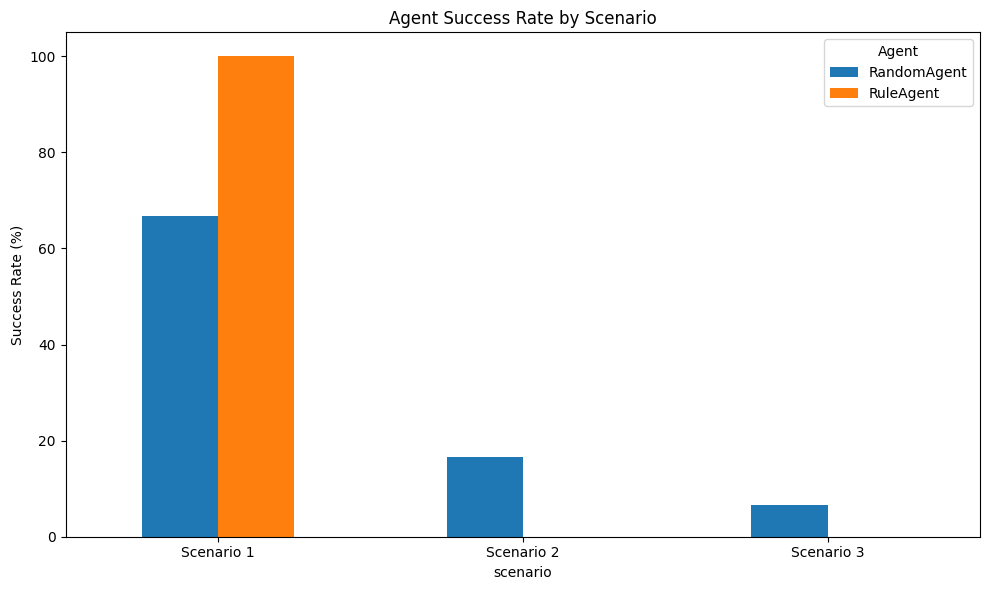

In [9]:
import matplotlib.pyplot as plt

# 将成功率转换为表格形式，便于绘图
success_table = success_rate.unstack()

# 绘制柱状图
fig, ax = plt.subplots(figsize=(10, 6))
success_table.plot(kind='bar', ax=ax)
ax.set_ylabel('Success Rate (%)')
ax.set_title('Agent Success Rate by Scenario')
ax.legend(title='Agent')
ax.set_xticklabels(['Scenario 1', 'Scenario 2', 'Scenario 3'], rotation=0)
plt.tight_layout()
plt.show()

In [10]:
# 查看失败的 episode
failed = last_steps[~last_steps['success']]
print("失败的 episode 示例（每个场景-代理取前3个）:")
print(failed.groupby(['scenario', 'agent']).head(3)[['episode', 'step', 'collected', 'total_items', 'pos_x', 'pos_y']])

失败的 episode 示例（每个场景-代理取前3个）:
    episode  step  collected  total_items  pos_x  pos_y
0         0   199          0            1      4      4
2         0   199          1            3      1      2
3         0   147          1            3      3      0
4         0   199          0            2      3      2
5         0   184          1            2      3      4
8         1   199          1            3      4      2
9         1   184          1            3      3      0
10        1   199          1            2      2      2
11        1   165          1            2      3      4
14        2   199          1            3      2      2
15        2   171          1            3      3      0
16        2   199          1            2      3      4
17        2   180          1            2      3      4
18        3   199          0            1      1      2
36        6   199          0            1      3      1


In [12]:
import json
import os

# 直接用当前工作目录（项目根目录）
project_dir = os.getcwd()
scenarios_dir = os.path.join(project_dir, 'scenarios')

for scene_name in ['scenario1', 'scenario2', 'scenario3']:
    file_path = os.path.join(scenarios_dir, f'{scene_name}.json')
    with open(file_path, 'r') as f:
        grid = json.load(f)
    count = sum(row.count('I') for row in grid)
    print(f'{scene_name}: {count} 个物品')


scenario1: 1 个物品
scenario2: 3 个物品
scenario3: 3 个物品


In [13]:
# 修正后的物品数量（根据实际统计）
item_counts = {
    'scenario1': 1,
    'scenario2': 3,
    'scenario3': 3   # 修正为 3
}

# 重新计算每个 episode 的最后一步和成功率
last_steps = df.groupby(['episode', 'scenario', 'agent']).last().reset_index()
last_steps['total_items'] = last_steps['scenario'].map(item_counts)
last_steps['success'] = (last_steps['done'] == True) & (last_steps['collected'] == last_steps['total_items'])

# 重新计算成功率
success_rate = last_steps.groupby(['scenario', 'agent'])['success'].mean() * 100
print("修正后的成功率 (%):")
print(success_rate)

修正后的成功率 (%):
scenario   agent      
scenario1  RandomAgent     66.666667
           RuleAgent      100.000000
scenario2  RandomAgent     16.666667
           RuleAgent        0.000000
scenario3  RandomAgent      0.000000
           RuleAgent        0.000000
Name: success, dtype: float64


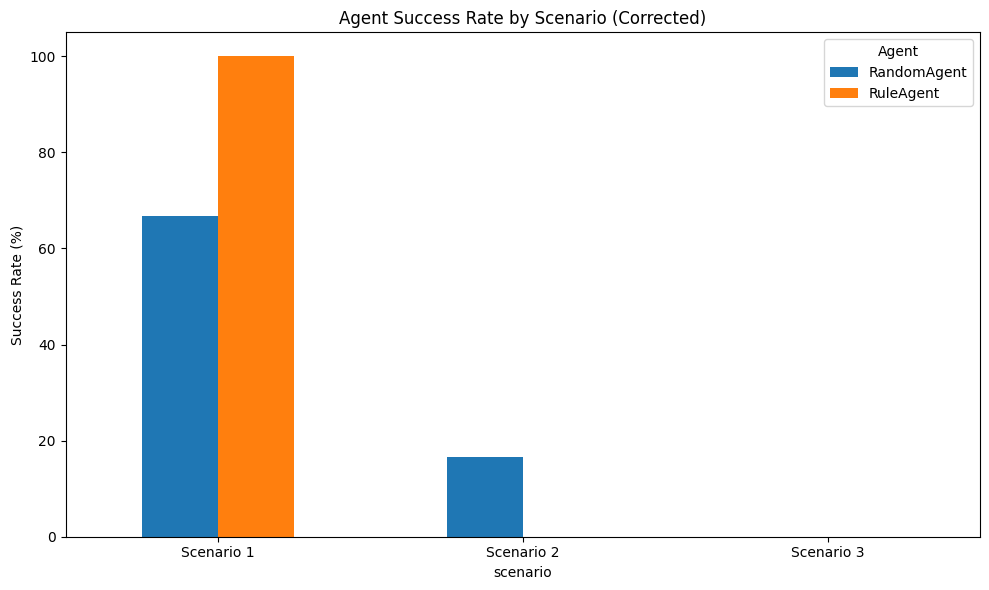

In [14]:
import matplotlib.pyplot as plt

success_table = success_rate.unstack()
fig, ax = plt.subplots(figsize=(10, 6))
success_table.plot(kind='bar', ax=ax)
ax.set_ylabel('Success Rate (%)')
ax.set_title('Agent Success Rate by Scenario (Corrected)')
ax.legend(title='Agent')
ax.set_xticklabels(['Scenario 1', 'Scenario 2', 'Scenario 3'], rotation=0)
plt.tight_layout()
plt.show()

In [15]:
failed = last_steps[~last_steps['success']]
print("修正后的失败 episode 示例（每个场景-代理取前3个）:")
print(failed.groupby(['scenario', 'agent']).head(3)[['episode', 'step', 'collected', 'total_items', 'pos_x', 'pos_y']])

修正后的失败 episode 示例（每个场景-代理取前3个）:
    episode  step  collected  total_items  pos_x  pos_y
0         0   199          0            1      4      4
2         0   199          1            3      1      2
3         0   147          1            3      3      0
4         0   199          0            3      3      2
5         0   184          1            3      3      4
8         1   199          1            3      4      2
9         1   184          1            3      3      0
10        1   199          1            3      2      2
11        1   165          1            3      3      4
14        2   199          1            3      2      2
15        2   171          1            3      3      0
16        2   199          1            3      3      4
17        2   180          1            3      3      4
18        3   199          0            1      1      2
36        6   199          0            1      3      1


In [16]:
last_steps['collect_ratio'] = last_steps['collected'] / last_steps['total_items']
avg_ratio = last_steps.groupby(['scenario', 'agent'])['collect_ratio'].mean() * 100
print("修正后的平均收集率 (%):")
print(avg_ratio)

修正后的平均收集率 (%):
scenario   agent      
scenario1  RandomAgent     66.666667
           RuleAgent      100.000000
scenario2  RandomAgent     50.000000
           RuleAgent       33.333333
scenario3  RandomAgent     24.444444
           RuleAgent       30.000000
Name: collect_ratio, dtype: float64


In [17]:
# 查看 RuleAgent 在场景2中 episode 0 的轨迹
traj = df[(df['scenario']=='scenario2') & (df['agent']=='RuleAgent') & (df['episode']==0)]
print(traj[['step', 'pos_x', 'pos_y', 'action', 'collected']])

       step  pos_x  pos_y   action  collected
12049     0      1      0     down          0
12050     1      2      0     down          0
12051     2      1      0       up          0
12052     3      0      0       up          0
12053     4      1      0     down          0
...     ...    ...    ...      ...        ...
12192   143      3      0  collect          1
12193   144      3      0  collect          1
12194   145      3      0  collect          1
12195   146      3      0  collect          1
12196   147      3      0  collect          1

[148 rows x 5 columns]


In [18]:
# 从 last_steps 中筛选 RandomAgent 成功的 episode
random_success = last_steps[(last_steps['agent'] == 'RandomAgent') & (last_steps['success'] == True)]

print("RandomAgent 成功的 episode 列表：")
print(random_success[['scenario', 'episode', 'step', 'collected', 'pos_x', 'pos_y']])

RandomAgent 成功的 episode 列表：
      scenario  episode  step  collected  pos_x  pos_y
6    scenario1        1   199          1      4      0
12   scenario1        2    18          1      0      4
24   scenario1        4   151          1      0      4
30   scenario1        5    67          1      0      4
42   scenario1        7   144          1      0      4
44   scenario2        7   177          3      0      4
48   scenario1        8   199          1      0      3
54   scenario1        9   173          1      0      4
60   scenario1       10   199          1      4      0
66   scenario1       11   132          1      0      4
72   scenario1       12    82          1      0      4
78   scenario1       13    21          1      0      4
84   scenario1       14   169          1      0      4
90   scenario1       15   199          1      0      2
92   scenario2       15   176          3      0      4
96   scenario1       16    29          1      0      4
98   scenario2       16   190        

In [19]:
# 假设你想查看第一个成功案例的轨迹（可根据上面的列表修改场景和episode）
if len(random_success) > 0:
    example = random_success.iloc[0]  # 取第一个成功案例
    scen = example['scenario']
    ep = example['episode']
    print(f"\n查看 {scen} episode {ep} 的完整轨迹：")
    
    # 从原始数据 df 中筛选该 episode 的所有步骤
    traj = df[(df['scenario'] == scen) & (df['agent'] == 'RandomAgent') & (df['episode'] == ep)]
    print(traj[['step', 'pos_x', 'pos_y', 'action', 'collected']])
else:
    print("没有 RandomAgent 成功的案例。")


查看 scenario1 episode 1 的完整轨迹：
     step  pos_x  pos_y   action  collected
200     0      0      0     left          0
201     1      1      0     down          0
202     2      1      0  collect          0
203     3      1      1    right          0
204     4      1      2    right          0
..    ...    ...    ...      ...        ...
395   195      4      0     down          1
396   196      4      0  collect          1
397   197      4      1    right          1
398   198      4      0     left          1
399   199      4      0  collect          1

[200 rows x 5 columns]


In [20]:
scen = 'scenario1'
ep = 2  # 替换为你想看的 episode 编号
traj = df[(df['scenario'] == scen) & (df['agent'] == 'RandomAgent') & (df['episode'] == ep)]
print(traj[['step', 'pos_x', 'pos_y', 'action', 'collected']])

     step  pos_x  pos_y   action  collected
400     0      0      0     left          0
401     1      0      0  collect          0
402     2      1      0     down          0
403     3      1      1    right          0
404     4      0      1       up          0
405     5      0      1  collect          0
406     6      1      1     down          0
407     7      1      1  collect          0
408     8      1      1  collect          0
409     9      1      0     left          0
410    10      2      0     down          0
411    11      1      0       up          0
412    12      0      0       up          0
413    13      0      1    right          0
414    14      0      2    right          0
415    15      0      2       up          0
416    16      0      3    right          0
417    17      0      3  collect          1
418    18      0      4    right          1


In [21]:
import json

# 读取每个场景的目标点坐标
goal_positions = {}
scenarios_dir = os.path.join(os.getcwd(), 'scenarios')
for scene in ['scenario1', 'scenario2', 'scenario3']:
    with open(os.path.join(scenarios_dir, f'{scene}.json')) as f:
        grid = json.load(f)
    # 查找G
    goal = None
    for i, row in enumerate(grid):
        for j, cell in enumerate(row):
            if cell == 'G':
                goal = (i, j)
                break
        if goal:
            break
    goal_positions[scene] = goal

# 重新定义成功：最后一步收集数等于总数，且位置等于目标点
last_steps = df.groupby(['episode', 'scenario', 'agent']).last().reset_index()
last_steps['total_items'] = last_steps['scenario'].map(item_counts)
# 添加目标点列
last_steps['goal'] = last_steps['scenario'].map(goal_positions)
last_steps['at_goal'] = (last_steps['pos_x'] == last_steps['goal'].apply(lambda x: x[0])) & (last_steps['pos_y'] == last_steps['goal'].apply(lambda x: x[1]))
last_steps['success'] = (last_steps['collected'] == last_steps['total_items']) & last_steps['at_goal']

# 计算成功率
new_success_rate = last_steps.groupby(['scenario', 'agent'])['success'].mean() * 100
print(new_success_rate)

scenario   agent      
scenario1  RandomAgent     53.333333
           RuleAgent      100.000000
scenario2  RandomAgent     13.333333
           RuleAgent        0.000000
scenario3  RandomAgent      0.000000
           RuleAgent        0.000000
Name: success, dtype: float64


In [22]:
# 选择一个场景2的 RuleAgent 失败案例
traj = df[(df['scenario']=='scenario2') & (df['agent']=='RuleAgent') & (df['episode']==0)]
print(traj[['step', 'pos_x', 'pos_y', 'action', 'collected']])

       step  pos_x  pos_y   action  collected
12049     0      1      0     down          0
12050     1      2      0     down          0
12051     2      1      0       up          0
12052     3      0      0       up          0
12053     4      1      0     down          0
...     ...    ...    ...      ...        ...
12192   143      3      0  collect          1
12193   144      3      0  collect          1
12194   145      3      0  collect          1
12195   146      3      0  collect          1
12196   147      3      0  collect          1

[148 rows x 5 columns]


In [23]:
# 选择一个场景2的 RandomAgent 成功案例
traj = df[(df['scenario']=='scenario2') & (df['agent']=='RandomAgent') & (df['episode']==7)]
print(traj[['step', 'pos_x', 'pos_y', 'action', 'collected']])

      step  pos_x  pos_y   action  collected
7556     0      0      0  collect          0
7557     1      0      0     left          0
7558     2      1      0     down          0
7559     3      0      0       up          0
7560     4      0      0  collect          0
...    ...    ...    ...      ...        ...
7729   173      0      3       up          2
7730   174      1      3     down          2
7731   175      1      3  collect          3
7732   176      1      4    right          3
7733   177      0      4       up          3

[178 rows x 5 columns]


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import os

# ---------- 读取日志 ----------
cwd = os.getcwd()
if os.path.basename(cwd) == 'evaluation':
    base_dir = os.path.dirname(cwd)
else:
    base_dir = cwd
log_path = os.path.join(base_dir, 'logs', 'evaluation_logs.csv')
df = pd.read_csv(log_path)

# ---------- 物品数量（已确定） ----------
item_counts = {
    'scenario1': 1,
    'scenario2': 3,
    'scenario3': 3
}

# ---------- 读取每个场景的目标点 ----------
goal_positions = {}
scenarios_dir = os.path.join(base_dir, 'scenarios')
for scene in ['scenario1', 'scenario2', 'scenario3']:
    with open(os.path.join(scenarios_dir, f'{scene}.json')) as f:
        grid = json.load(f)
    goal = None
    for i, row in enumerate(grid):
        for j, cell in enumerate(row):
            if cell == 'G':
                goal = (i, j)
                break
        if goal:
            break
    goal_positions[scene] = goal
print("目标点坐标：", goal_positions)

# ---------- 计算每个 episode 的最后一步 ----------
last_steps = df.groupby(['episode', 'scenario', 'agent']).last().reset_index()
last_steps['total_items'] = last_steps['scenario'].map(item_counts)
last_steps['goal'] = last_steps['scenario'].map(goal_positions)
last_steps['at_goal'] = (last_steps['pos_x'] == last_steps['goal'].apply(lambda x: x[0])) & (last_steps['pos_y'] == last_steps['goal'].apply(lambda x: x[1]))
last_steps['success'] = (last_steps['collected'] == last_steps['total_items']) & last_steps['at_goal']

# ---------- 计算成功率 ----------
success_rate = last_steps.groupby(['scenario', 'agent'])['success'].mean() * 100
print("\n【修正后的成功率（考虑目标点）】")
print(success_rate)

目标点坐标： {'scenario1': (0, 4), 'scenario2': (0, 4), 'scenario3': (2, 5)}

【修正后的成功率（考虑目标点）】
scenario   agent            
scenario1  AdvancedRuleAgent    100.000000
           RandomAgent           50.000000
           RuleAgent             90.000000
scenario2  AdvancedRuleAgent     40.000000
           RandomAgent            6.666667
           RuleAgent              0.000000
scenario3  AdvancedRuleAgent      0.000000
           RandomAgent            0.000000
           RuleAgent              0.000000
Name: success, dtype: float64


In [2]:
# 查看场景3 AdvancedRuleAgent episode 0 的轨迹
traj = df[(df['scenario']=='scenario3') & (df['agent']=='AdvancedRuleAgent') & (df['episode']==0)]
print(traj[['step', 'pos_x', 'pos_y', 'action', 'collected']])

       step  pos_x  pos_y action  collected
31435     0      0      1  right          0
31436     1      0      0   left          0
31437     2      0      1  right          0
31438     3      0      0   left          0
31439     4      0      1  right          0
...     ...    ...    ...    ...        ...
31526    91      2      4   left          2
31527    92      2      5  right          2
31528    93      2      4   left          2
31529    94      2      5  right          2
31530    95      3      5   down          2

[96 rows x 5 columns]


日志加载成功，数据量： (34884, 9)

目标点坐标： {'scenario1': (0, 4), 'scenario2': (0, 4), 'scenario3': (2, 5)}

【修正后的成功率（考虑目标点）】
scenario   agent            
scenario1  AdvancedRuleAgent    100.00
           RandomAgent           36.67
           RuleAgent             90.00
scenario2  AdvancedRuleAgent     36.67
           RandomAgent            3.33
           RuleAgent              0.00
scenario3  AdvancedRuleAgent      0.00
           RandomAgent            3.33
           RuleAgent              0.00
Name: success, dtype: float64


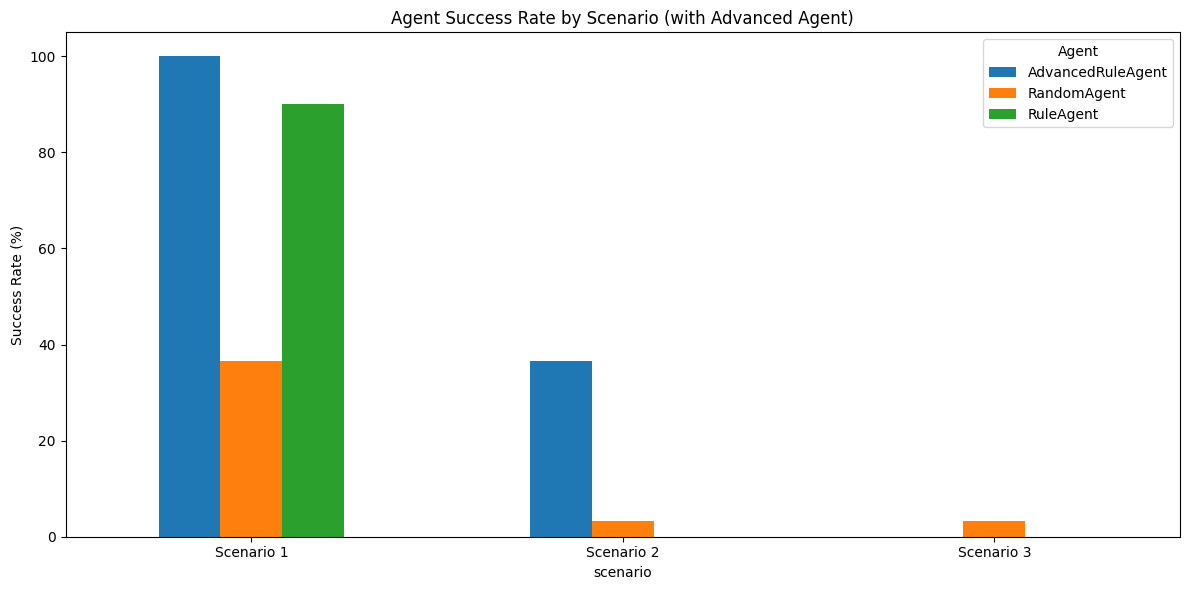


各 Agent 成功案例数（共30次）：
agent      AdvancedRuleAgent  RandomAgent  RuleAgent
scenario                                            
scenario1                 30           11         27
scenario2                 11            1          0
scenario3                  0            1          0


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import os

# ---------- 自动定位项目根目录 ----------
cwd = os.getcwd()
if os.path.basename(cwd) == 'evaluation':
    base_dir = os.path.dirname(cwd)
else:
    base_dir = cwd

# ---------- 读取日志 ----------
log_path = os.path.join(base_dir, 'logs', 'evaluation_logs.csv')
df = pd.read_csv(log_path)
print("日志加载成功，数据量：", df.shape)

# ---------- 物品数量（已确认） ----------
item_counts = {
    'scenario1': 1,
    'scenario2': 3,
    'scenario3': 3
}

# ---------- 读取每个场景的目标点坐标 ----------
goal_positions = {}
scenarios_dir = os.path.join(base_dir, 'scenarios')
for scene in ['scenario1', 'scenario2', 'scenario3']:
    with open(os.path.join(scenarios_dir, f'{scene}.json')) as f:
        grid = json.load(f)
    goal = None
    for i, row in enumerate(grid):
        for j, cell in enumerate(row):
            if cell == 'G':
                goal = (i, j)
                break
        if goal:
            break
    goal_positions[scene] = goal
print("\n目标点坐标：", goal_positions)

# ---------- 计算每个 episode 的最后一步 ----------
last_steps = df.groupby(['episode', 'scenario', 'agent']).last().reset_index()
last_steps['total_items'] = last_steps['scenario'].map(item_counts)
last_steps['goal'] = last_steps['scenario'].map(goal_positions)
last_steps['at_goal'] = (last_steps['pos_x'] == last_steps['goal'].apply(lambda x: x[0])) & (last_steps['pos_y'] == last_steps['goal'].apply(lambda x: x[1]))
last_steps['success'] = (last_steps['collected'] == last_steps['total_items']) & last_steps['at_goal']

# ---------- 计算成功率 ----------
success_rate = last_steps.groupby(['scenario', 'agent'])['success'].mean() * 100
print("\n【修正后的成功率（考虑目标点）】")
print(success_rate.round(2))

# ---------- 绘制柱状图对比 ----------
success_table = success_rate.unstack()
fig, ax = plt.subplots(figsize=(12,6))
success_table.plot(kind='bar', ax=ax)
ax.set_ylabel('Success Rate (%)')
ax.set_title('Agent Success Rate by Scenario (with Advanced Agent)')
ax.legend(title='Agent')
ax.set_xticklabels(['Scenario 1', 'Scenario 2', 'Scenario 3'], rotation=0)
plt.tight_layout()
plt.show()

# ---------- 可选：查看成功案例数量 ----------
print("\n各 Agent 成功案例数（共30次）：")
print(last_steps[last_steps['success']].groupby(['scenario','agent']).size().unstack(fill_value=0))

In [3]:
# 计算场景3中各 Agent 的平均收集率
last_steps['collect_ratio'] = last_steps['collected'] / last_steps['total_items']
avg_ratio = last_steps[last_steps['scenario']=='scenario3'].groupby('agent')['collect_ratio'].mean() * 100
print("场景3 平均收集率 (%):")
print(avg_ratio.round(2))

场景3 平均收集率 (%):
agent
AdvancedRuleAgent    47.78
RandomAgent          34.44
RuleAgent            32.22
Name: collect_ratio, dtype: float64


In [4]:
traj = df[(df['scenario']=='scenario3') & (df['agent']=='AdvancedRuleAgent') & (df['episode']==0)]
print(traj[['step', 'pos_x', 'pos_y', 'action', 'collected']])

       step  pos_x  pos_y action  collected
32178     0      0      1  right          0
32179     1      0      0   left          0
32180     2      0      1  right          0
32181     3      0      0   left          0
32182     4      1      0   down          0
...     ...    ...    ...    ...        ...
32262    84      0      5  right          2
32263    85      0      4   left          2
32264    86      0      5  right          2
32265    87      0      4   left          2
32266    88      0      5  right          2

[89 rows x 5 columns]


In [5]:
# 查看 RandomAgent 在场景3的成功案例
success_rand = last_steps[(last_steps['agent']=='RandomAgent') & (last_steps['success']==True) & (last_steps['scenario']=='scenario3')]
if not success_rand.empty:
    ep = success_rand.iloc[0]['episode']
    print(f"RandomAgent 成功 episode {ep} 的轨迹：")
    traj_rand = df[(df['scenario']=='scenario3') & (df['agent']=='RandomAgent') & (df['episode']==ep)]
    print(traj_rand[['step', 'pos_x', 'pos_y', 'action', 'collected']])
else:
    print("无 RandomAgent 成功案例")

RandomAgent 成功 episode 8 的轨迹：
       step  pos_x  pos_y   action  collected
22693     0      0      0  collect          0
22694     1      1      0     down          0
22695     2      1      0     left          0
22696     3      2      0     down          0
22697     4      2      0     down          0
...     ...    ...    ...      ...        ...
22831   138      3      5       up          2
22832   139      3      4     left          2
22833   140      3      4  collect          3
22834   141      3      5    right          3
22835   142      2      5       up          3

[143 rows x 5 columns]


日志加载成功，总行数： 32826
Agent 类型： <StringArray>
['RandomAgent', 'RuleAgent', 'AdvancedRuleAgent']
Length: 3, dtype: str
场景： <StringArray>
['scenario1', 'scenario2', 'scenario3']
Length: 3, dtype: str

目标点坐标： {'scenario1': (0, 4), 'scenario2': (0, 4), 'scenario3': (2, 5)}

【修正后的成功率（考虑目标点）】
scenario   agent            
scenario1  AdvancedRuleAgent    100.00
           RandomAgent           50.00
           RuleAgent             96.67
scenario2  AdvancedRuleAgent    100.00
           RandomAgent            6.67
           RuleAgent              0.00
scenario3  AdvancedRuleAgent      0.00
           RandomAgent            0.00
           RuleAgent              0.00
Name: success, dtype: float64


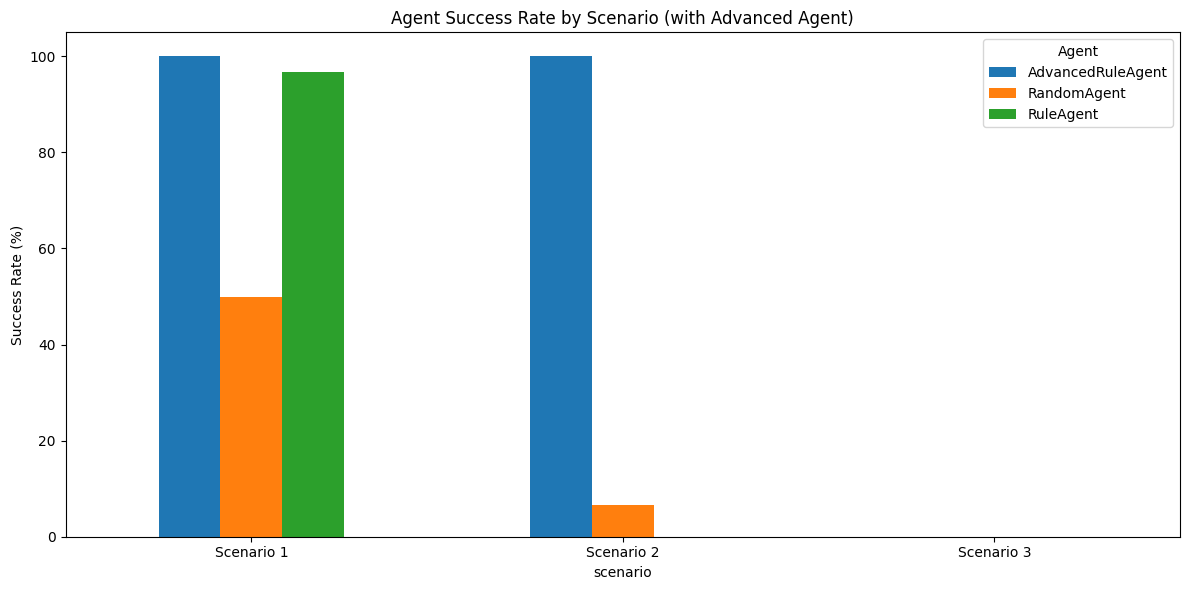


各 Agent 成功案例数（共30次）：
agent      AdvancedRuleAgent  RandomAgent  RuleAgent
scenario                                            
scenario1                 30           15         29
scenario2                 30            2          0

【平均收集率（%）】
scenario   agent            
scenario1  AdvancedRuleAgent    100.00
           RandomAgent           63.33
           RuleAgent            100.00
scenario2  AdvancedRuleAgent    100.00
           RandomAgent           54.44
           RuleAgent             33.33
scenario3  AdvancedRuleAgent     48.89
           RandomAgent           38.89
           RuleAgent             33.33
Name: collect_ratio, dtype: float64


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import os

# ---------- 自动定位项目根目录 ----------
cwd = os.getcwd()
if os.path.basename(cwd) == 'evaluation':
    base_dir = os.path.dirname(cwd)
else:
    base_dir = cwd

# ---------- 读取最新日志 ----------
log_path = os.path.join(base_dir, 'logs', 'evaluation_logs.csv')
df = pd.read_csv(log_path)
print("日志加载成功，总行数：", len(df))
print("Agent 类型：", df['agent'].unique())
print("场景：", df['scenario'].unique())

# ---------- 物品数量（已确认） ----------
item_counts = {
    'scenario1': 1,
    'scenario2': 3,
    'scenario3': 3
}

# ---------- 读取每个场景的目标点坐标 ----------
goal_positions = {}
scenarios_dir = os.path.join(base_dir, 'scenarios')
for scene in ['scenario1', 'scenario2', 'scenario3']:
    with open(os.path.join(scenarios_dir, f'{scene}.json')) as f:
        grid = json.load(f)
    goal = None
    for i, row in enumerate(grid):
        for j, cell in enumerate(row):
            if cell == 'G':
                goal = (i, j)
                break
        if goal:
            break
    goal_positions[scene] = goal
print("\n目标点坐标：", goal_positions)

# ---------- 计算每个 episode 的最后一步 ----------
last_steps = df.groupby(['episode', 'scenario', 'agent']).last().reset_index()
last_steps['total_items'] = last_steps['scenario'].map(item_counts)
last_steps['goal'] = last_steps['scenario'].map(goal_positions)
last_steps['at_goal'] = (last_steps['pos_x'] == last_steps['goal'].apply(lambda x: x[0])) & (last_steps['pos_y'] == last_steps['goal'].apply(lambda x: x[1]))
last_steps['success'] = (last_steps['collected'] == last_steps['total_items']) & last_steps['at_goal']

# ---------- 计算成功率 ----------
success_rate = last_steps.groupby(['scenario', 'agent'])['success'].mean() * 100
print("\n【修正后的成功率（考虑目标点）】")
print(success_rate.round(2))

# ---------- 绘制柱状图对比 ----------
success_table = success_rate.unstack()
fig, ax = plt.subplots(figsize=(12,6))
success_table.plot(kind='bar', ax=ax)
ax.set_ylabel('Success Rate (%)')
ax.set_title('Agent Success Rate by Scenario (with Advanced Agent)')
ax.legend(title='Agent')
ax.set_xticklabels(['Scenario 1', 'Scenario 2', 'Scenario 3'], rotation=0)
plt.tight_layout()
plt.show()

# ---------- 输出成功案例数量（共30次） ----------
print("\n各 Agent 成功案例数（共30次）：")
success_counts = last_steps[last_steps['success']].groupby(['scenario','agent']).size().unstack(fill_value=0)
print(success_counts)

# ---------- 可选：计算平均收集率 ----------
last_steps['collect_ratio'] = last_steps['collected'] / last_steps['total_items']
avg_ratio = last_steps.groupby(['scenario', 'agent'])['collect_ratio'].mean() * 100
print("\n【平均收集率（%）】")
print(avg_ratio.round(2))

In [2]:
# 场景3各 Agent 平均收集物品数
last_steps_3 = last_steps[last_steps['scenario']=='scenario3']
avg_collect = last_steps_3.groupby('agent')['collected'].mean()
print("场景3各 Agent 平均收集物品数（共3个）：")
print(avg_collect)

# AdvancedRuleAgent 是否有收集到3个物品的 episode
full_collect = last_steps_3[(last_steps_3['agent']=='AdvancedRuleAgent') & (last_steps_3['collected']==3)]
print(f"\nAdvancedRuleAgent 收集到3个物品的 episode 数：{len(full_collect)} / 30")
if len(full_collect) > 0:
    # 检查这些 episode 是否到达目标
    full_collect['at_goal'] = (full_collect['pos_x'] == full_collect['goal'].apply(lambda x: x[0])) & (full_collect['pos_y'] == full_collect['goal'].apply(lambda x: x[1]))
    print("到达目标的情况：")
    print(full_collect[['episode','at_goal']])

    # 如果有收集全但没到达目标的，选第一个查看轨迹
    not_at_goal = full_collect[~full_collect['at_goal']]
    if not not_at_goal.empty:
        ep = not_at_goal.iloc[0]['episode']
        traj = df[(df['scenario']=='scenario3') & (df['agent']=='AdvancedRuleAgent') & (df['episode']==ep)]
        print(f"\nAdvancedRuleAgent 场景3 episode {ep} 的完整轨迹（收集全但未到目标）：")
        print(traj[['step','pos_x','pos_y','action','collected']])
    else:
        print("所有收集全的 episode 都到达了目标？那成功率应该不是0，请检查。")
else:
    print("没有收集到3个物品的 episode，说明探索阶段就有问题。")

场景3各 Agent 平均收集物品数（共3个）：
agent
AdvancedRuleAgent    1.466667
RandomAgent          1.166667
RuleAgent            1.000000
Name: collected, dtype: float64

AdvancedRuleAgent 收集到3个物品的 episode 数：0 / 30
没有收集到3个物品的 episode，说明探索阶段就有问题。


日志加载成功，总行数： 33357
Agent 类型： <StringArray>
['RandomAgent', 'RuleAgent', 'AdvancedRuleAgent']
Length: 3, dtype: str
场景： <StringArray>
['scenario1', 'scenario2', 'scenario3']
Length: 3, dtype: str

目标点坐标： {'scenario1': (0, 4), 'scenario2': (0, 4), 'scenario3': (2, 5)}

【修正后的成功率（考虑目标点）】
scenario   agent            
scenario1  AdvancedRuleAgent    100.00
           RandomAgent           56.67
           RuleAgent             86.67
scenario2  AdvancedRuleAgent    100.00
           RandomAgent            6.67
           RuleAgent              0.00
scenario3  AdvancedRuleAgent      0.00
           RandomAgent            3.33
           RuleAgent              0.00
Name: success, dtype: float64


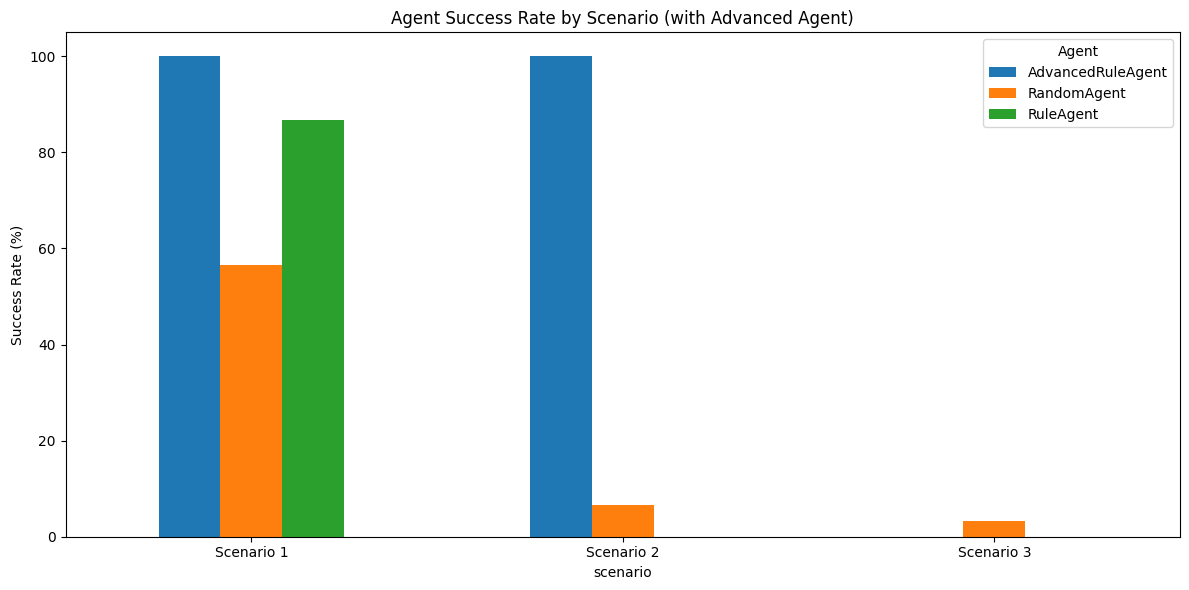


各 Agent 成功案例数（共30次）：
agent      AdvancedRuleAgent  RandomAgent  RuleAgent
scenario                                            
scenario1                 30           17         26
scenario2                 30            2          0
scenario3                  0            1          0

【平均收集物品数】
scenario   agent            
scenario1  AdvancedRuleAgent    1.00
           RandomAgent          0.67
           RuleAgent            1.00
scenario2  AdvancedRuleAgent    3.00
           RandomAgent          1.67
           RuleAgent            1.00
scenario3  AdvancedRuleAgent    1.00
           RandomAgent          1.03
           RuleAgent            1.00
Name: collected, dtype: float64

【平均收集率（%）】
scenario   agent            
scenario1  AdvancedRuleAgent    100.00
           RandomAgent           66.67
           RuleAgent            100.00
scenario2  AdvancedRuleAgent    100.00
           RandomAgent           55.56
           RuleAgent             33.33
scenario3  AdvancedRuleAgent     

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import os

# ---------- 自动定位项目根目录 ----------
cwd = os.getcwd()
if os.path.basename(cwd) == 'evaluation':
    base_dir = os.path.dirname(cwd)
else:
    base_dir = cwd

# ---------- 读取最新日志 ----------
log_path = os.path.join(base_dir, 'logs', 'evaluation_logs.csv')
df = pd.read_csv(log_path)
print("日志加载成功，总行数：", len(df))
print("Agent 类型：", df['agent'].unique())
print("场景：", df['scenario'].unique())

# ---------- 物品数量（已确认） ----------
item_counts = {
    'scenario1': 1,
    'scenario2': 3,
    'scenario3': 3
}

# ---------- 读取每个场景的目标点坐标 ----------
goal_positions = {}
scenarios_dir = os.path.join(base_dir, 'scenarios')
for scene in ['scenario1', 'scenario2', 'scenario3']:
    with open(os.path.join(scenarios_dir, f'{scene}.json')) as f:
        grid = json.load(f)
    goal = None
    for i, row in enumerate(grid):
        for j, cell in enumerate(row):
            if cell == 'G':
                goal = (i, j)
                break
        if goal:
            break
    goal_positions[scene] = goal
print("\n目标点坐标：", goal_positions)

# ---------- 计算每个 episode 的最后一步 ----------
last_steps = df.groupby(['episode', 'scenario', 'agent']).last().reset_index()
last_steps['total_items'] = last_steps['scenario'].map(item_counts)
last_steps['goal'] = last_steps['scenario'].map(goal_positions)
last_steps['at_goal'] = (last_steps['pos_x'] == last_steps['goal'].apply(lambda x: x[0])) & (last_steps['pos_y'] == last_steps['goal'].apply(lambda x: x[1]))
last_steps['success'] = (last_steps['collected'] == last_steps['total_items']) & last_steps['at_goal']

# ---------- 计算成功率 ----------
success_rate = last_steps.groupby(['scenario', 'agent'])['success'].mean() * 100
print("\n【修正后的成功率（考虑目标点）】")
print(success_rate.round(2))

# ---------- 绘制柱状图对比 ----------
success_table = success_rate.unstack()
fig, ax = plt.subplots(figsize=(12,6))
success_table.plot(kind='bar', ax=ax)
ax.set_ylabel('Success Rate (%)')
ax.set_title('Agent Success Rate by Scenario (with Advanced Agent)')
ax.legend(title='Agent')
ax.set_xticklabels(['Scenario 1', 'Scenario 2', 'Scenario 3'], rotation=0)
plt.tight_layout()
plt.show()

# ---------- 输出成功案例数量（共30次） ----------
print("\n各 Agent 成功案例数（共30次）：")
success_counts = last_steps[last_steps['success']].groupby(['scenario','agent']).size().unstack(fill_value=0)
print(success_counts)

# ---------- 计算平均收集物品数 ----------
avg_collected = last_steps.groupby(['scenario','agent'])['collected'].mean().round(2)
print("\n【平均收集物品数】")
print(avg_collected)

# ---------- 计算平均收集率（百分比） ----------
last_steps['collect_ratio'] = last_steps['collected'] / last_steps['total_items']
avg_ratio = last_steps.groupby(['scenario', 'agent'])['collect_ratio'].mean() * 100
print("\n【平均收集率（%）】")
print(avg_ratio.round(2))

# ---------- 针对场景3的深入分析 ----------
print("\n===== 场景3详细分析 =====")
scene3 = last_steps[last_steps['scenario']=='scenario3']
for agent in scene3['agent'].unique():
    agent_data = scene3[scene3['agent']==agent]
    full_collect = agent_data[agent_data['collected']==3]
    print(f"{agent}: 平均收集 {agent_data['collected'].mean():.2f} 个物品，收集全3个物品的 episode 数：{len(full_collect)} / 30")
    if len(full_collect) > 0:
        # 检查收集全的 episode 中到达目标的比例
        at_goal = full_collect['at_goal'].sum()
        print(f"  其中到达目标的次数：{at_goal}")

In [3]:
# 场景3各Agent的平均步数
last_steps_scene3 = last_steps[last_steps['scenario']=='scenario3']
print(last_steps_scene3.groupby('agent')['step'].mean())

agent
AdvancedRuleAgent     99.000000
RandomAgent          198.666667
RuleAgent            170.833333
Name: step, dtype: float64


In [4]:
traj = df[(df['scenario']=='scenario3') & (df['agent']=='AdvancedRuleAgent') & (df['episode']==0)]
print(traj[['step','pos_x','pos_y','action','collected']])

       step  pos_x  pos_y action  collected
30357     0      0      1  right          0
30358     1      0      0   left          0
30359     2      1      0   down          0
30360     3      2      0   down          0
30361     4      2      1  right          0
...     ...    ...    ...    ...        ...
30444    87      1      2   left          1
30445    88      1      3  right          1
30446    89      1      2   left          1
30447    90      1      3  right          1
30448    91      1      2   left          1

[92 rows x 5 columns]


In [5]:
import json
with open('scenarios/scenario3.json') as f:
    grid = json.load(f)
for i, row in enumerate(grid):
    for j, cell in enumerate(row):
        print(f'({i},{j}): {cell}')

(0,0): S
(0,1): .
(0,2): W
(0,3): W
(0,4): .
(0,5): .
(1,0): .
(1,1): W
(1,2): .
(1,3): I
(1,4): W
(1,5): .
(2,0): .
(2,1): .
(2,2): .
(2,3): W
(2,4): .
(2,5): G
(3,0): W
(3,1): W
(3,2): .
(3,3): .
(3,4): I
(3,5): .
(4,0): .
(4,1): .
(4,2): W
(4,3): .
(4,4): .
(4,5): .
(5,0): .
(5,1): .
(5,2): .
(5,3): W
(5,4): .
(5,5): I


日志加载成功，总行数： 34684
Agent 类型： <StringArray>
['RandomAgent', 'RuleAgent', 'AdvancedRuleAgent']
Length: 3, dtype: str
场景： <StringArray>
['scenario1', 'scenario2', 'scenario3']
Length: 3, dtype: str

目标点坐标： {'scenario1': (0, 4), 'scenario2': (0, 4), 'scenario3': (2, 5)}

【修正后的成功率（考虑目标点）】
scenario   agent            
scenario1  AdvancedRuleAgent    100.00
           RandomAgent           53.33
           RuleAgent             90.00
scenario2  AdvancedRuleAgent      0.00
           RandomAgent            6.67
           RuleAgent              0.00
scenario3  AdvancedRuleAgent      0.00
           RandomAgent            3.33
           RuleAgent              0.00
Name: success, dtype: float64


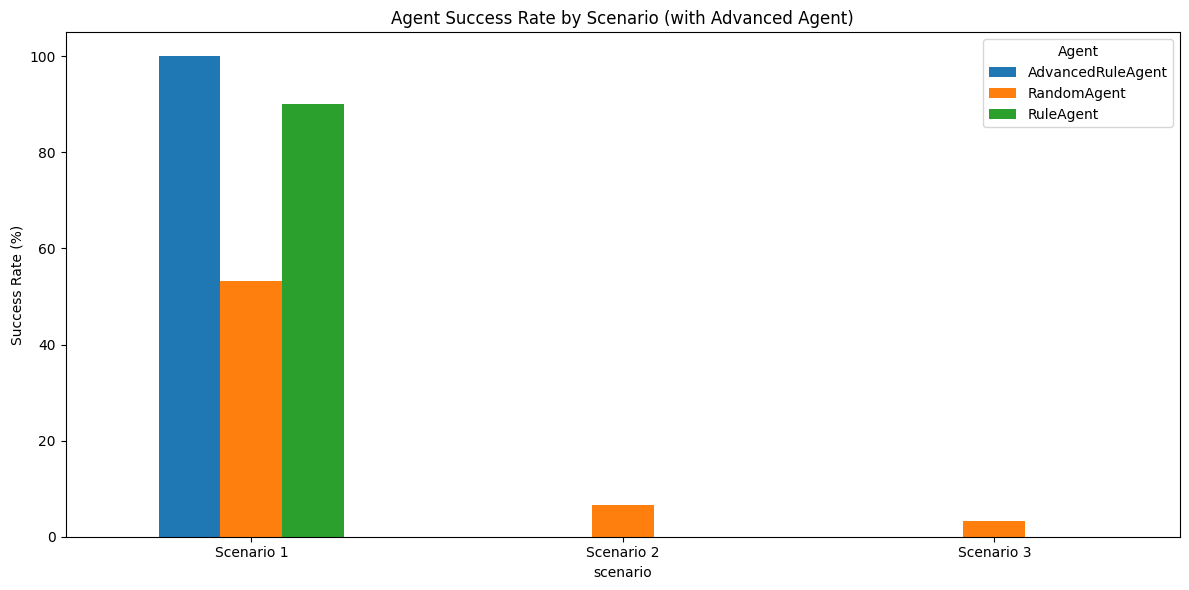


各 Agent 成功案例数（共30次）：
agent      AdvancedRuleAgent  RandomAgent  RuleAgent
scenario                                            
scenario1                 30           16         27
scenario2                  0            2          0
scenario3                  0            1          0

【平均收集物品数】
scenario   agent            
scenario1  AdvancedRuleAgent    1.00
           RandomAgent          0.70
           RuleAgent            1.00
scenario2  AdvancedRuleAgent    0.00
           RandomAgent          1.50
           RuleAgent            1.00
scenario3  AdvancedRuleAgent    0.00
           RandomAgent          1.03
           RuleAgent            0.87
Name: collected, dtype: float64

【平均收集率（%）】
scenario   agent            
scenario1  AdvancedRuleAgent    100.00
           RandomAgent           70.00
           RuleAgent            100.00
scenario2  AdvancedRuleAgent      0.00
           RandomAgent           50.00
           RuleAgent             33.33
scenario3  AdvancedRuleAgent     

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import os

# ---------- 自动定位项目根目录 ----------
cwd = os.getcwd()
if os.path.basename(cwd) == 'evaluation':
    base_dir = os.path.dirname(cwd)
else:
    base_dir = cwd

# ---------- 读取最新日志 ----------
log_path = os.path.join(base_dir, 'logs', 'evaluation_logs.csv')
df = pd.read_csv(log_path)
print("日志加载成功，总行数：", len(df))
print("Agent 类型：", df['agent'].unique())
print("场景：", df['scenario'].unique())

# ---------- 物品数量（已确认） ----------
item_counts = {
    'scenario1': 1,
    'scenario2': 3,
    'scenario3': 3
}

# ---------- 读取每个场景的目标点坐标 ----------
goal_positions = {}
scenarios_dir = os.path.join(base_dir, 'scenarios')
for scene in ['scenario1', 'scenario2', 'scenario3']:
    with open(os.path.join(scenarios_dir, f'{scene}.json')) as f:
        grid = json.load(f)
    goal = None
    for i, row in enumerate(grid):
        for j, cell in enumerate(row):
            if cell == 'G':
                goal = (i, j)
                break
        if goal:
            break
    goal_positions[scene] = goal
print("\n目标点坐标：", goal_positions)

# ---------- 计算每个 episode 的最后一步 ----------
last_steps = df.groupby(['episode', 'scenario', 'agent']).last().reset_index()
last_steps['total_items'] = last_steps['scenario'].map(item_counts)
last_steps['goal'] = last_steps['scenario'].map(goal_positions)
last_steps['at_goal'] = (last_steps['pos_x'] == last_steps['goal'].apply(lambda x: x[0])) & (last_steps['pos_y'] == last_steps['goal'].apply(lambda x: x[1]))
last_steps['success'] = (last_steps['collected'] == last_steps['total_items']) & last_steps['at_goal']

# ---------- 计算成功率 ----------
success_rate = last_steps.groupby(['scenario', 'agent'])['success'].mean() * 100
print("\n【修正后的成功率（考虑目标点）】")
print(success_rate.round(2))

# ---------- 绘制柱状图对比 ----------
success_table = success_rate.unstack()
fig, ax = plt.subplots(figsize=(12,6))
success_table.plot(kind='bar', ax=ax)
ax.set_ylabel('Success Rate (%)')
ax.set_title('Agent Success Rate by Scenario (with Advanced Agent)')
ax.legend(title='Agent')
ax.set_xticklabels(['Scenario 1', 'Scenario 2', 'Scenario 3'], rotation=0)
plt.tight_layout()
plt.show()

# ---------- 输出成功案例数量（共30次） ----------
print("\n各 Agent 成功案例数（共30次）：")
success_counts = last_steps[last_steps['success']].groupby(['scenario','agent']).size().unstack(fill_value=0)
print(success_counts)

# ---------- 计算平均收集物品数 ----------
avg_collected = last_steps.groupby(['scenario','agent'])['collected'].mean().round(2)
print("\n【平均收集物品数】")
print(avg_collected)

# ---------- 计算平均收集率（百分比） ----------
last_steps['collect_ratio'] = last_steps['collected'] / last_steps['total_items']
avg_ratio = last_steps.groupby(['scenario', 'agent'])['collect_ratio'].mean() * 100
print("\n【平均收集率（%）】")
print(avg_ratio.round(2))

# ---------- 针对场景3的深入分析 ----------
print("\n===== 场景3详细分析 =====")
scene3 = last_steps[last_steps['scenario']=='scenario3']
for agent in scene3['agent'].unique():
    agent_data = scene3[scene3['agent']==agent]
    full_collect = agent_data[agent_data['collected']==3]
    print(f"{agent}: 平均收集 {agent_data['collected'].mean():.2f} 个物品，收集全3个物品的 episode 数：{len(full_collect)} / 30")
    if len(full_collect) > 0:
        # 检查收集全的 episode 中到达目标的比例
        at_goal = full_collect['at_goal'].sum()
        print(f"  其中到达目标的次数：{at_goal}")

# ---------- 可选：查看某个失败episode的轨迹（请根据实际输出修改episode编号） ----------
# 如果想查看特定episode的轨迹，可以取消下面的注释并修改episode编号
# ep = 0
# traj = df[(df['scenario']=='scenario3') & (df['agent']=='AdvancedRuleAgent') & (df['episode']==ep)]
# print(f"\nAdvancedRuleAgent 场景3 episode {ep} 的轨迹：")
# print(traj[['step','pos_x','pos_y','action','collected']])

日志加载成功，总行数： 33734
Agent 类型： <StringArray>
['RandomAgent', 'RuleAgent', 'AdvancedRuleAgent']
Length: 3, dtype: str
场景： <StringArray>
['scenario1', 'scenario2', 'scenario3']
Length: 3, dtype: str

目标点坐标： {'scenario1': (0, 4), 'scenario2': (0, 4), 'scenario3': (2, 5)}

【修正后的成功率（考虑目标点）】
scenario   agent            
scenario1  AdvancedRuleAgent    100.00
           RandomAgent           50.00
           RuleAgent             76.67
scenario2  AdvancedRuleAgent    100.00
           RandomAgent            3.33
           RuleAgent              0.00
scenario3  AdvancedRuleAgent      0.00
           RandomAgent            3.33
           RuleAgent              0.00
Name: success, dtype: float64


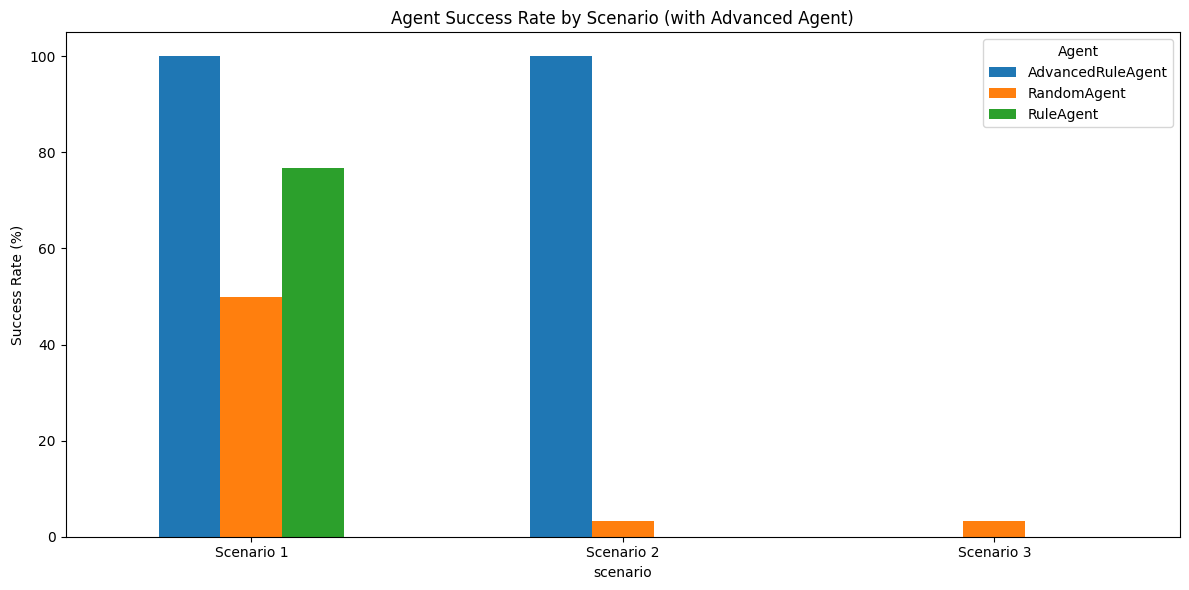


各 Agent 成功案例数（共30次）：
agent      AdvancedRuleAgent  RandomAgent  RuleAgent
scenario                                            
scenario1                 30           15         23
scenario2                 30            1          0
scenario3                  0            1          0

【平均收集物品数】
scenario   agent            
scenario1  AdvancedRuleAgent    1.00
           RandomAgent          0.63
           RuleAgent            0.93
scenario2  AdvancedRuleAgent    3.00
           RandomAgent          1.43
           RuleAgent            1.00
scenario3  AdvancedRuleAgent    1.00
           RandomAgent          1.33
           RuleAgent            0.97
Name: collected, dtype: float64

【平均收集率（%）】
scenario   agent            
scenario1  AdvancedRuleAgent    100.00
           RandomAgent           63.33
           RuleAgent             93.33
scenario2  AdvancedRuleAgent    100.00
           RandomAgent           47.78
           RuleAgent             33.33
scenario3  AdvancedRuleAgent     

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import os

# ---------- 自动定位项目根目录 ----------
cwd = os.getcwd()
if os.path.basename(cwd) == 'evaluation':
    base_dir = os.path.dirname(cwd)
else:
    base_dir = cwd

# ---------- 读取最新日志 ----------
log_path = os.path.join(base_dir, 'logs', 'evaluation_logs.csv')
df = pd.read_csv(log_path)
print("日志加载成功，总行数：", len(df))
print("Agent 类型：", df['agent'].unique())
print("场景：", df['scenario'].unique())

# ---------- 物品数量（已确认） ----------
item_counts = {
    'scenario1': 1,
    'scenario2': 3,
    'scenario3': 3
}

# ---------- 读取每个场景的目标点坐标 ----------
goal_positions = {}
scenarios_dir = os.path.join(base_dir, 'scenarios')
for scene in ['scenario1', 'scenario2', 'scenario3']:
    with open(os.path.join(scenarios_dir, f'{scene}.json')) as f:
        grid = json.load(f)
    goal = None
    for i, row in enumerate(grid):
        for j, cell in enumerate(row):
            if cell == 'G':
                goal = (i, j)
                break
        if goal:
            break
    goal_positions[scene] = goal
print("\n目标点坐标：", goal_positions)

# ---------- 计算每个 episode 的最后一步 ----------
last_steps = df.groupby(['episode', 'scenario', 'agent']).last().reset_index()
last_steps['total_items'] = last_steps['scenario'].map(item_counts)
last_steps['goal'] = last_steps['scenario'].map(goal_positions)
last_steps['at_goal'] = (last_steps['pos_x'] == last_steps['goal'].apply(lambda x: x[0])) & (last_steps['pos_y'] == last_steps['goal'].apply(lambda x: x[1]))
last_steps['success'] = (last_steps['collected'] == last_steps['total_items']) & last_steps['at_goal']

# ---------- 计算成功率 ----------
success_rate = last_steps.groupby(['scenario', 'agent'])['success'].mean() * 100
print("\n【修正后的成功率（考虑目标点）】")
print(success_rate.round(2))

# ---------- 绘制柱状图对比 ----------
success_table = success_rate.unstack()
fig, ax = plt.subplots(figsize=(12,6))
success_table.plot(kind='bar', ax=ax)
ax.set_ylabel('Success Rate (%)')
ax.set_title('Agent Success Rate by Scenario (with Advanced Agent)')
ax.legend(title='Agent')
ax.set_xticklabels(['Scenario 1', 'Scenario 2', 'Scenario 3'], rotation=0)
plt.tight_layout()
plt.show()

# ---------- 输出成功案例数量（共30次） ----------
print("\n各 Agent 成功案例数（共30次）：")
success_counts = last_steps[last_steps['success']].groupby(['scenario','agent']).size().unstack(fill_value=0)
print(success_counts)

# ---------- 计算平均收集物品数 ----------
avg_collected = last_steps.groupby(['scenario','agent'])['collected'].mean().round(2)
print("\n【平均收集物品数】")
print(avg_collected)

# ---------- 计算平均收集率（百分比） ----------
last_steps['collect_ratio'] = last_steps['collected'] / last_steps['total_items']
avg_ratio = last_steps.groupby(['scenario', 'agent'])['collect_ratio'].mean() * 100
print("\n【平均收集率（%）】")
print(avg_ratio.round(2))

# ---------- 针对场景3的深入分析 ----------
print("\n===== 场景3详细分析 =====")
scene3 = last_steps[last_steps['scenario']=='scenario3']
for agent in scene3['agent'].unique():
    agent_data = scene3[scene3['agent']==agent]
    full_collect = agent_data[agent_data['collected']==3]
    print(f"{agent}: 平均收集 {agent_data['collected'].mean():.2f} 个物品，收集全3个物品的 episode 数：{len(full_collect)} / 30")
    if len(full_collect) > 0:
        # 检查收集全的 episode 中到达目标的比例
        at_goal = full_collect['at_goal'].sum()
        print(f"  其中到达目标的次数：{at_goal}")

# ---------- 可选：查看某个失败episode的轨迹（请根据实际输出修改episode编号） ----------
# 如果想查看特定episode的轨迹，可以取消下面的注释并修改episode编号
# ep = 0
# traj = df[(df['scenario']=='scenario3') & (df['agent']=='AdvancedRuleAgent') & (df['episode']==ep)]
# print(f"\nAdvancedRuleAgent 场景3 episode {ep} 的轨迹：")
# print(traj[['step','pos_x','pos_y','action','collected']])

日志加载成功，总行数： 33408
Agent 类型： <StringArray>
['RandomAgent', 'RuleAgent', 'AdvancedRuleAgent']
Length: 3, dtype: str
场景： <StringArray>
['scenario1', 'scenario2', 'scenario3']
Length: 3, dtype: str

目标点坐标： {'scenario1': (0, 4), 'scenario2': (0, 4), 'scenario3': (2, 5)}

【修正后的成功率（考虑目标点）】
scenario   agent            
scenario1  AdvancedRuleAgent    100.00
           RandomAgent           66.67
           RuleAgent             90.00
scenario2  AdvancedRuleAgent    100.00
           RandomAgent            0.00
           RuleAgent              0.00
scenario3  AdvancedRuleAgent      0.00
           RandomAgent            6.67
           RuleAgent              0.00
Name: success, dtype: float64


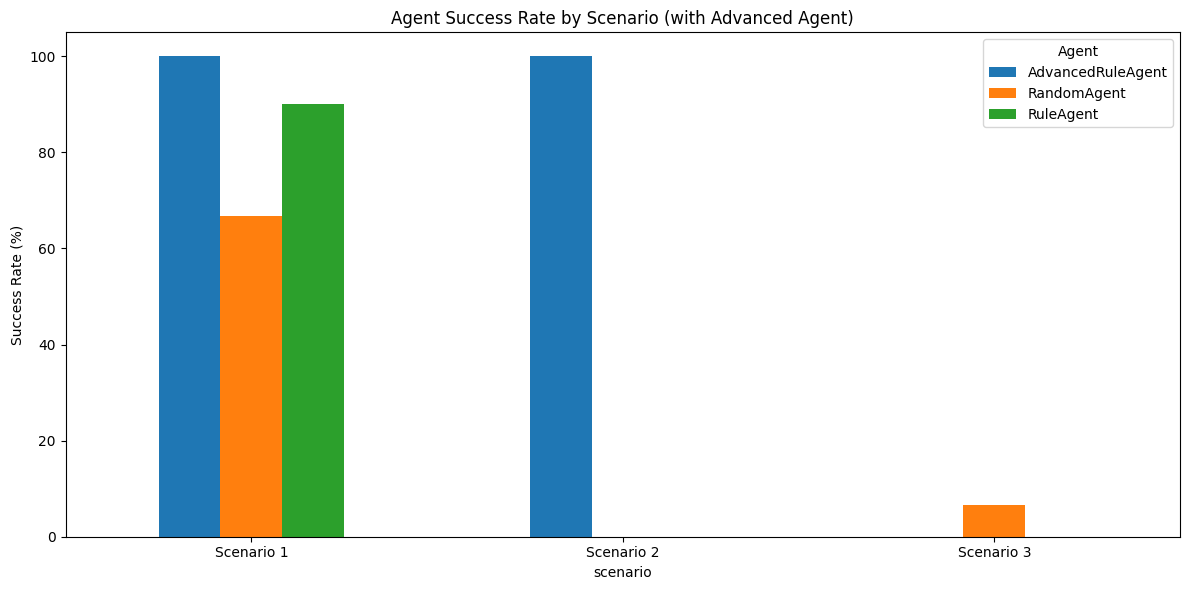


各 Agent 成功案例数（共30次）：
agent      AdvancedRuleAgent  RandomAgent  RuleAgent
scenario                                            
scenario1                 30           20         27
scenario2                 30            0          0
scenario3                  0            2          0

【平均收集物品数】
scenario   agent            
scenario1  AdvancedRuleAgent    1.00
           RandomAgent          0.73
           RuleAgent            1.00
scenario2  AdvancedRuleAgent    3.00
           RandomAgent          1.83
           RuleAgent            1.00
scenario3  AdvancedRuleAgent    1.00
           RandomAgent          1.50
           RuleAgent            1.00
Name: collected, dtype: float64

【平均收集率（%）】
scenario   agent            
scenario1  AdvancedRuleAgent    100.00
           RandomAgent           73.33
           RuleAgent            100.00
scenario2  AdvancedRuleAgent    100.00
           RandomAgent           61.11
           RuleAgent             33.33
scenario3  AdvancedRuleAgent     

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import os

# ---------- 自动定位项目根目录 ----------
cwd = os.getcwd()
if os.path.basename(cwd) == 'evaluation':
    base_dir = os.path.dirname(cwd)
else:
    base_dir = cwd

# ---------- 读取最新日志 ----------
log_path = os.path.join(base_dir, 'logs', 'evaluation_logs.csv')
df = pd.read_csv(log_path)
print("日志加载成功，总行数：", len(df))
print("Agent 类型：", df['agent'].unique())
print("场景：", df['scenario'].unique())

# ---------- 物品数量（已确认） ----------
item_counts = {
    'scenario1': 1,
    'scenario2': 3,
    'scenario3': 3
}

# ---------- 读取每个场景的目标点坐标 ----------
goal_positions = {}
scenarios_dir = os.path.join(base_dir, 'scenarios')
for scene in ['scenario1', 'scenario2', 'scenario3']:
    with open(os.path.join(scenarios_dir, f'{scene}.json')) as f:
        grid = json.load(f)
    goal = None
    for i, row in enumerate(grid):
        for j, cell in enumerate(row):
            if cell == 'G':
                goal = (i, j)
                break
        if goal:
            break
    goal_positions[scene] = goal
print("\n目标点坐标：", goal_positions)

# ---------- 计算每个 episode 的最后一步 ----------
last_steps = df.groupby(['episode', 'scenario', 'agent']).last().reset_index()
last_steps['total_items'] = last_steps['scenario'].map(item_counts)
last_steps['goal'] = last_steps['scenario'].map(goal_positions)
last_steps['at_goal'] = (last_steps['pos_x'] == last_steps['goal'].apply(lambda x: x[0])) & (last_steps['pos_y'] == last_steps['goal'].apply(lambda x: x[1]))
last_steps['success'] = (last_steps['collected'] == last_steps['total_items']) & last_steps['at_goal']

# ---------- 计算成功率 ----------
success_rate = last_steps.groupby(['scenario', 'agent'])['success'].mean() * 100
print("\n【修正后的成功率（考虑目标点）】")
print(success_rate.round(2))

# ---------- 绘制柱状图对比 ----------
success_table = success_rate.unstack()
fig, ax = plt.subplots(figsize=(12,6))
success_table.plot(kind='bar', ax=ax)
ax.set_ylabel('Success Rate (%)')
ax.set_title('Agent Success Rate by Scenario (with Advanced Agent)')
ax.legend(title='Agent')
ax.set_xticklabels(['Scenario 1', 'Scenario 2', 'Scenario 3'], rotation=0)
plt.tight_layout()
plt.show()

# ---------- 输出成功案例数量（共30次） ----------
print("\n各 Agent 成功案例数（共30次）：")
success_counts = last_steps[last_steps['success']].groupby(['scenario','agent']).size().unstack(fill_value=0)
print(success_counts)

# ---------- 计算平均收集物品数 ----------
avg_collected = last_steps.groupby(['scenario','agent'])['collected'].mean().round(2)
print("\n【平均收集物品数】")
print(avg_collected)

# ---------- 计算平均收集率（百分比） ----------
last_steps['collect_ratio'] = last_steps['collected'] / last_steps['total_items']
avg_ratio = last_steps.groupby(['scenario', 'agent'])['collect_ratio'].mean() * 100
print("\n【平均收集率（%）】")
print(avg_ratio.round(2))

# ---------- 针对场景3的深入分析 ----------
print("\n===== 场景3详细分析 =====")
scene3 = last_steps[last_steps['scenario']=='scenario3']
for agent in scene3['agent'].unique():
    agent_data = scene3[scene3['agent']==agent]
    full_collect = agent_data[agent_data['collected']==3]
    print(f"{agent}: 平均收集 {agent_data['collected'].mean():.2f} 个物品，收集全3个物品的 episode 数：{len(full_collect)} / 30")
    if len(full_collect) > 0:
        # 检查收集全的 episode 中到达目标的比例
        at_goal = full_collect['at_goal'].sum()
        print(f"  其中到达目标的次数：{at_goal}")

# ---------- 可选：查看某个失败episode的轨迹（请根据实际输出修改episode编号） ----------
# 如果想查看特定episode的轨迹，可以取消下面的注释并修改episode编号
# ep = 0
# traj = df[(df['scenario']=='scenario3') & (df['agent']=='AdvancedRuleAgent') & (df['episode']==ep)]
# print(f"\nAdvancedRuleAgent 场景3 episode {ep} 的轨迹：")
# print(traj[['step','pos_x','pos_y','action','collected']])